# 03 — Prompt-Curve Translation (DE-LU)

Turn the DA price forecast into a tradable prompt-curve view:
**fair value (with bands) → edge vs a market anchor → confidence-weighted signal → desk action + invalidation.**

Market anchor = trailing 30-day realised average (transparent proxy for the prompt forward; no paid data used).

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import curve, forecast as fc
from src.features import model_frame, TARGET
import pandas as pd

df = model_frame()
_, oos = fc.cross_validate(df)
test, preds_by_model, _ = fc.final_test(df)
hgb = preds_by_model["hgb"]
fv = fc.curve_view(test, hgb, fc.daily_residuals(oos), horizon_days=30)
fv

{'baseload_forecast': 77.65,
 'baseload_actual': 94.47,
 'peak_forecast': 55.39,
 'peak_actual': 76.04,
 'baseload_P10': 83.38,
 'baseload_P50': 86.47,
 'baseload_P90': 89.69}

## Signals: level (baseload) and shape (peak/base)

In [2]:
delivery_start = test.index.min()
prices = df[TARGET]
base_anchor = curve.market_anchor(prices, delivery_start)
peak_anchor = curve.market_anchor(prices[df["is_peak"] == 1], delivery_start)

print("LEVEL:", curve.level_signal(fv, base_anchor))
print("SHAPE:", curve.shape_signal(fv, base_anchor, peak_anchor))

LEVEL: {'anchor': 84.44, 'fair_value_P50': 86.47, 'edge_eur_mwh': 2.03, 'band_halfwidth': 3.16, 'z_score': 0.64, 'direction': 'FLAT', 'position_mw': 0.0, 'note': 'edge within forecast band -> stand aside'}
SHAPE: {'fv_peak_base_spread': -22.26, 'anchor_peak_base_spread': -20.19, 'spread_edge_eur_mwh': -2.07, 'direction': 'SHORT peak/base spread'}


## Invalidation checks
Concrete conditions under which the desk drops the trade.

In [3]:
for name, ok, detail in curve.invalidation_checks(test, fv):
    print(f"{'PASS' if ok else 'FAIL'} - {name} ({detail})")

FAIL - Realised avg within P10-P90 band (actual 94.47 vs [83.38, 89.69])
PASS - Renewable forecast drift <= 15% (realised vs forecast renewables drift +0.7%)


## Full report + figure
Writes `outputs/curve_view.md` and the figure (also prints the desk playbook + invalidation rules).

In [4]:
curve.main()

Fitting model (walk-forward) and forecasting the delivery period...



=== Level signal (baseload) ===
  anchor: 84.44
  fair_value_P50: 86.47
  edge_eur_mwh: 2.03
  band_halfwidth: 3.16
  z_score: 0.64
  direction: FLAT
  position_mw: 0.0
  note: edge within forecast band -> stand aside

=== Shape signal (peak vs base) ===
  fv_peak_base_spread: -22.26
  anchor_peak_base_spread: -20.19
  spread_edge_eur_mwh: -2.07
  direction: SHORT peak/base spread

=== Invalidation checks ===
  FAIL - Realised avg within P10-P90 band (actual 94.47 vs [83.38, 89.69])
  PASS - Renewable forecast drift <= 15% (realised vs forecast renewables drift +0.7%)

Report -> /Users/mhmdshakerr/Desktop/Cobble Stone Energy/European-Power-Fair-Value/outputs/curve_view.md


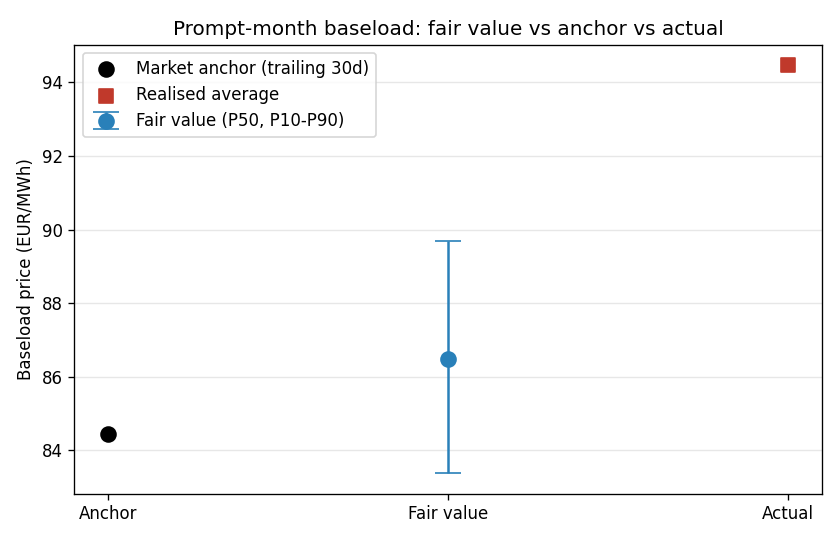

In [5]:
import config
from IPython.display import Image, display
display(Image(str(config.FIGURE_DIR / "curve_view.png")))